In [1]:
from pathlib import Path
import sys

current_path = Path.cwd()

if current_path.name == "notebooks":
    PROJECT_ROOT = current_path.parent
elif (current_path / "preprocess").exists():
    PROJECT_ROOT = current_path
else:
    PROJECT_ROOT = current_path
    while PROJECT_ROOT != PROJECT_ROOT.parent:
        if (PROJECT_ROOT / "preprocess").exists():
            break
        PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

print("Current path:", current_path)
print("Project root:", PROJECT_ROOT)
print("preprocess exists:", (PROJECT_ROOT / "preprocess").exists())
print("clean_double_knee.py exists:", (PROJECT_ROOT / "preprocess" / "clean_double_knee.py").exists())




Current path: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\notebook
Project root: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1
preprocess exists: True
clean_double_knee.py exists: True


In [8]:
from preprocess.clean_double_knee import create_cleaned_dataset

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw" / "Digital Knee X-ray Images" / "MedicalExpert-I"

CLEANED_DATA_DIR = PROJECT_ROOT / "data" / "processed" / "cleaned_images" / "MedicalExpert-I"

RESULTS_DIR = PROJECT_ROOT / "outputs" / "results"

print("Raw data dir:", RAW_DATA_DIR)
print("Cleaned data dir:", CLEANED_DATA_DIR)
print("Results dir:", RESULTS_DIR)

print("Raw data exists:", RAW_DATA_DIR.exists())

Raw data dir: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\data\raw\Digital Knee X-ray Images\MedicalExpert-I
Cleaned data dir: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\data\processed\cleaned_images\MedicalExpert-I
Results dir: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\results
Raw data exists: True


In [9]:
all_df, clean_df, removed_df, summary_df = create_cleaned_dataset(
    raw_data_dir=RAW_DATA_DIR,
    cleaned_data_dir=CLEANED_DATA_DIR,
    results_dir=RESULTS_DIR,
    overwrite=True,
    width_threshold=500,
    aspect_ratio_threshold=3.0,
)




Original images: 1650
Clean single-knee images: 1464
Removed double-knee candidates: 186

Copying clean images
Copied clean images to: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\data\processed\cleaned_images\MedicalExpert-I

Cleaning Summary
 label class_name  original_count  cleaned_count  removed_count
     0    0Normal             514            452             62
     1  1Doubtful             477            440             37
     2      2Mild             232            191             41
     3  3Moderate             221            175             46
     4    4Severe             206            206              0

Saved output files
C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\results\all_image_metadata.csv
C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\results\cleaned_dataset.csv
C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\results\removed_double_knee_candidates.csv
C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\results\

In [12]:
summary_df

print("Original images:", len(all_df))
print("Cleaned images:", len(clean_df))
print("Removed double-knee candidates:", len(removed_df))

removed_size_summary = (
    removed_df
    .groupby(["width", "height"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

removed_size_summary




Original images: 1650
Cleaned images: 1464
Removed double-knee candidates: 186


,width,height,count
0,640,161,186


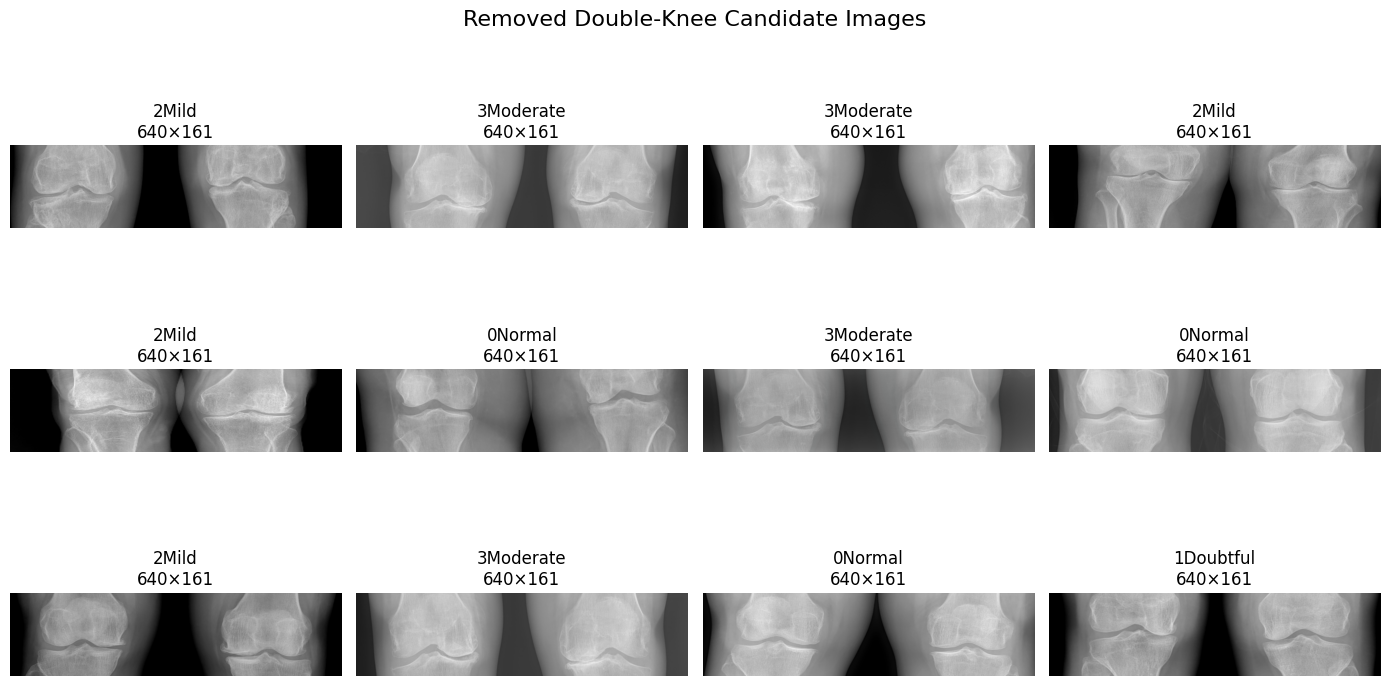

In [13]:
import matplotlib.pyplot as plt
from PIL import Image

sample_removed_df = removed_df.sample(
    n=min(12, len(removed_df)),
    random_state=42
)

plt.figure(figsize=(14, 8))

for i, (_, row) in enumerate(sample_removed_df.iterrows()):
    img = Image.open(row["image_path"])

    plt.subplot(3, 4, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(
        f'{row["class_name"]}\n'
        f'{row["width"]}×{row["height"]}'
    )
    plt.axis("off")

plt.suptitle("Removed Double-Knee Candidate Images", fontsize=16)
plt.tight_layout()
plt.show()




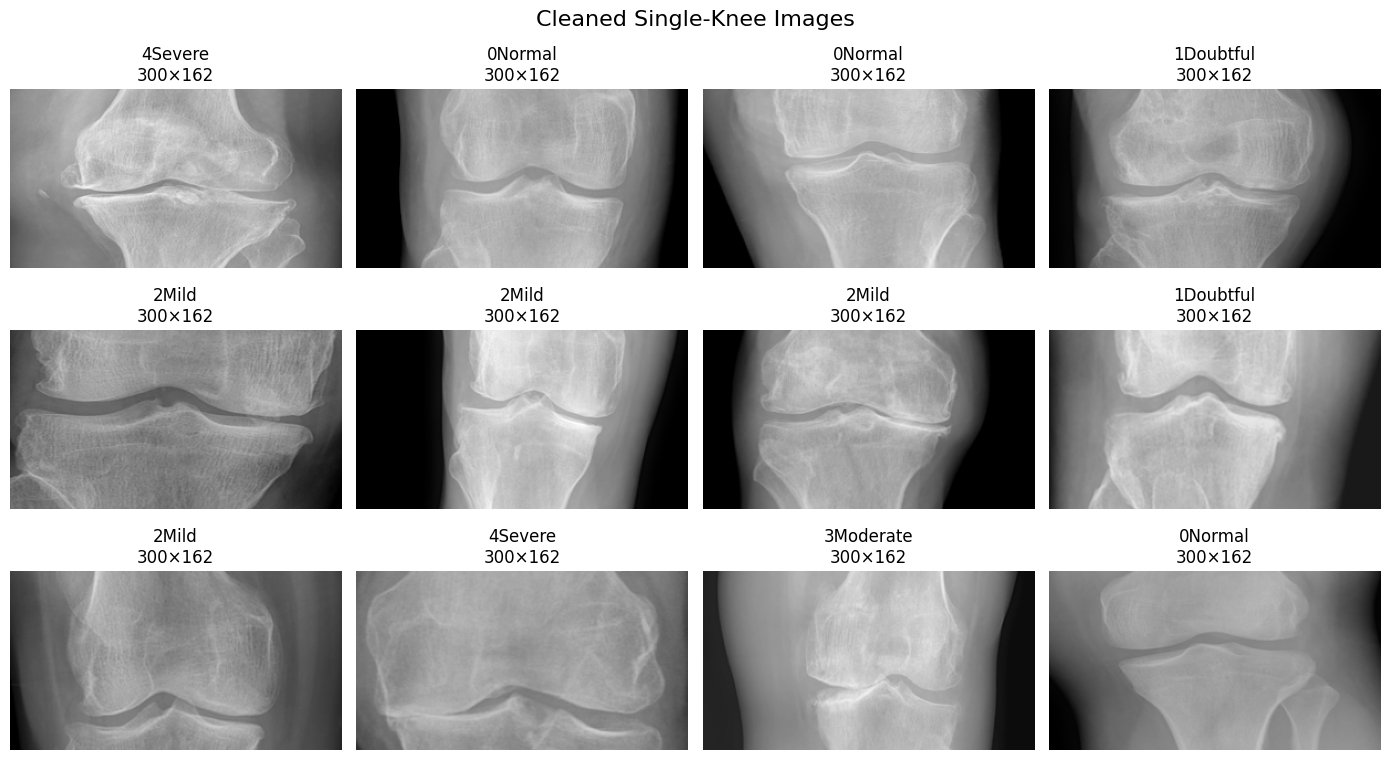

In [14]:
sample_clean_df = clean_df.sample(
    n=min(12, len(clean_df)),
    random_state=42
)

plt.figure(figsize=(14, 8))

for i, (_, row) in enumerate(sample_clean_df.iterrows()):
    img = Image.open(row["cleaned_image_path"])

    plt.subplot(3, 4, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(
        f'{row["class_name"]}\n'
        f'{row["width"]}×{row["height"]}'
    )
    plt.axis("off")

plt.suptitle("Cleaned Single-Knee Images", fontsize=16)
plt.tight_layout()
plt.show()




In [16]:
import pandas as pd
cleaned_folder_counts = []

for class_dir in sorted(CLEANED_DATA_DIR.iterdir()):
    if class_dir.is_dir():
        image_files = [
            p for p in class_dir.rglob("*")
            if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"]
        ]

        cleaned_folder_counts.append({
            "class_name": class_dir.name,
            "count": len(image_files)
        })

cleaned_folder_counts_df = pd.DataFrame(cleaned_folder_counts)
cleaned_folder_counts_df




,class_name,count
0,0Normal,452
1,1Doubtful,440
2,2Mild,191
3,3Moderate,175
4,4Severe,206


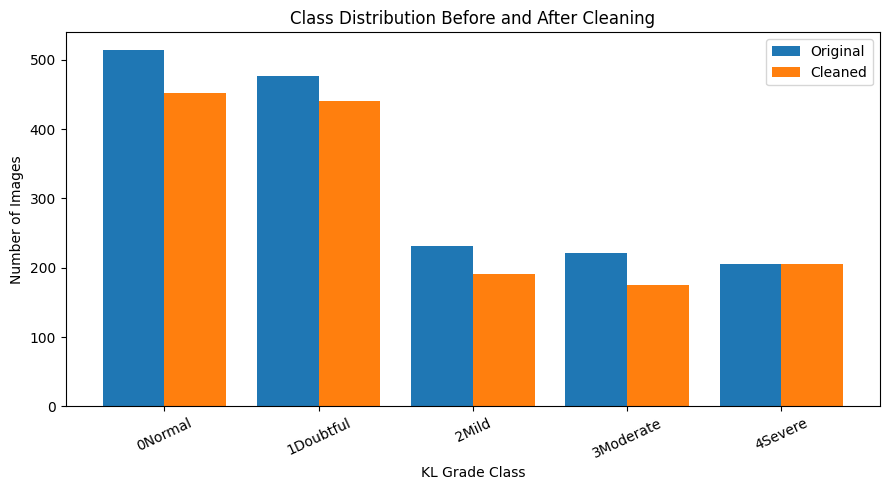

Saved figure to: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\figures\cleaning_before_after_distribution.png


In [17]:
import pandas as pd
import matplotlib.pyplot as plt

plot_df = summary_df.copy()

x = range(len(plot_df))

plt.figure(figsize=(9, 5))

plt.bar(
    [i - 0.2 for i in x],
    plot_df["original_count"],
    width=0.4,
    label="Original"
)

plt.bar(
    [i + 0.2 for i in x],
    plot_df["cleaned_count"],
    width=0.4,
    label="Cleaned"
)

plt.xticks(x, plot_df["class_name"], rotation=25)
plt.xlabel("KL Grade Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution Before and After Cleaning")
plt.legend()
plt.tight_layout()

figure_path = PROJECT_ROOT / "outputs" / "figures" / "cleaning_before_after_distribution.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)


